In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [3]:
import polars as pl
from config.rutas import RUTA_DATA_RAW

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de los Datos Crudos

In [18]:
df_crudo = pl.read_csv(RUTA_DATA_RAW / "endireh_2021.csv")
print(df_crudo.shape)
print(df_crudo.head())

(110127, 24)
shape: (5, 24)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ cve_entid ┆ nom_entid ┆ cve_munic ┆ nom_munic ┆ … ┆ propietar ┆ sufrio_vi ┆ factor_ex ┆ anio_enc │
│ ad        ┆ ad        ┆ ipio      ┆ ipio      ┆   ┆ ia_vivien ┆ olencia_p ┆ pansion   ┆ uesta    │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ da_desc   ┆ areja     ┆ ---       ┆ ---      │
│ i64       ┆ str       ┆ i64       ┆ str       ┆   ┆ ---       ┆ ---       ┆ i64       ┆ i64      │
│           ┆           ┆           ┆           ┆   ┆ str       ┆ i64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 1         ┆ AGUASCALI ┆ 1         ┆ AGUASCALI ┆ … ┆ Sí        ┆ 0         ┆ 113       ┆ 2021     │
│           ┆ ENTES     ┆           ┆ ENTES     ┆   ┆           ┆           ┆           ┆          │
│ 1         ┆ AGUASCALI ┆ 1         ┆ AGUASCALI ┆ … ┆ Sí       

In [23]:
lf = pl.scan_csv(RUTA_DATA_RAW / "endireh_2021.csv")
lf.collect_schema()   

Schema([('cve_entidad', Int64),
        ('nom_entidad', String),
        ('cve_municipio', Int64),
        ('nom_municipio', String),
        ('edad_primer_union', Float64),
        ('num_hijos', Float64),
        ('nivel_escolaridad', String),
        ('estado_civil_id', Int64),
        ('estado_civil_desc', String),
        ('estrato_socioeconomico', Int64),
        ('pareja_trabaja_id', Int64),
        ('pareja_trabaja_desc', String),
        ('ingreso_pareja', Float64),
        ('dinero_propio_id', Int64),
        ('dinero_propio_desc', String),
        ('apoyo_gobierno_id', Int64),
        ('apoyo_gobierno_desc', String),
        ('tiene_ahorros_id', Int64),
        ('tiene_ahorros_desc', String),
        ('propietaria_vivienda_id', Int64),
        ('propietaria_vivienda_desc', String),
        ('sufrio_violencia_pareja', Int64),
        ('factor_expansion', Int64),
        ('anio_encuesta', Int64)])

In [17]:
lf.head().collect() 

cve_entidad,nom_entidad,cve_municipio,nom_municipio,edad_primer_union,num_hijos,nivel_escolaridad,estado_civil_id,estado_civil_desc,estrato_socioeconomico,pareja_trabaja_id,pareja_trabaja_desc,ingreso_pareja,dinero_propio_id,dinero_propio_desc,apoyo_gobierno_id,apoyo_gobierno_desc,tiene_ahorros_id,tiene_ahorros_desc,propietaria_vivienda_id,propietaria_vivienda_desc,sufrio_violencia_pareja,factor_expansion,anio_encuesta
i64,str,i64,str,f64,f64,str,i64,str,i64,i64,str,f64,i64,str,i64,str,i64,str,i64,str,i64,i64,i64
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3.0,"""A1""",5,"""Casada""",4,1,"""Sí""",10000.0,1,"""Sí""",2,"""No""",2,"""No""",1,"""Sí""",0,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3.0,"""A1""",5,"""Casada""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",1,"""Sí""",1,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",13.0,3.0,"""B2""",4,"""Viuda""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",2,"""No""",0,227,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,null,"""C1""",6,"""Soltera""",4,1,"""Sí""",8500.0,1,"""Sí""",2,"""No""",1,"""Sí""",1,"""Sí""",0,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",20.0,3.0,"""B1""",2,"""Separada""",2,1,"""Sí""",400.0,1,"""Sí""",2,"""No""",2,"""No""",1,"""Sí""",1,155,2021


# Exploración

In [ ]:
schema = lf.collect_schema()
print("Columnas:", schema.names())
print("Cantidad de columnas:", schema.len())

n_filas = lf.select(pl.len()).collect().item()
print("Cantidad de filas:", n_filas)

Columnas: ['cve_entidad', 'nom_entidad', 'cve_municipio', 'nom_municipio', 'edad_primer_union', 'num_hijos', 'nivel_escolaridad', 'estado_civil_id', 'estado_civil_desc', 'estrato_socioeconomico', 'pareja_trabaja_id', 'pareja_trabaja_desc', 'ingreso_pareja', 'dinero_propio_id', 'dinero_propio_desc', 'apoyo_gobierno_id', 'apoyo_gobierno_desc', 'tiene_ahorros_id', 'tiene_ahorros_desc', 'propietaria_vivienda_id', 'propietaria_vivienda_desc', 'sufrio_violencia_pareja', 'factor_expansion', 'anio_encuesta']
Cantidad de columnas: 24
Cantidad de filas: 110127


In [19]:
lf.describe()

statistic,cve_entidad,nom_entidad,cve_municipio,nom_municipio,edad_primer_union,num_hijos,nivel_escolaridad,estado_civil_id,estado_civil_desc,estrato_socioeconomico,pareja_trabaja_id,pareja_trabaja_desc,ingreso_pareja,dinero_propio_id,dinero_propio_desc,apoyo_gobierno_id,apoyo_gobierno_desc,tiene_ahorros_id,tiene_ahorros_desc,propietaria_vivienda_id,propietaria_vivienda_desc,sufrio_violencia_pareja,factor_expansion,anio_encuesta
str,f64,str,f64,str,f64,f64,str,f64,str,f64,f64,str,f64,f64,str,f64,str,f64,str,f64,str,f64,f64,f64
"""count""",110127.0,"""110127""",110127.0,"""110127""",24560.0,90691.0,"""110127""",110127.0,"""110127""",110127.0,110127.0,"""110127""",48980.0,110127.0,"""110127""",110127.0,"""110127""",110127.0,"""110127""",110127.0,"""110127""",110127.0,110127.0,110127.0
"""null_count""",0.0,"""0""",0.0,"""0""",85567.0,19436.0,"""0""",0.0,"""0""",0.0,0.0,"""0""",61147.0,0.0,"""0""",0.0,"""0""",0.0,"""0""",0.0,"""0""",0.0,0.0,0.0
"""mean""",16.553861,null,38.830178,null,13.198453,2.517571,null,3.943347,null,2.180737,1.555241,null,86351.046039,1.476405,null,1.862214,null,1.89158,null,1.33722,null,0.175307,458.774588,2021.0
"""std""",9.205016,null,62.274657,null,19.508947,1.186904,null,1.844552,null,0.837085,0.496941,null,274695.849354,0.499445,null,0.344677,null,0.310912,null,0.472763,null,0.380231,513.055625,0.0
"""min""",1.0,"""AGUASCALIENTES""",1.0,"""ABALÃ""",0.0,1.0,"""A1""",1.0,"""Casada""",1.0,1.0,"""No""",0.0,1.0,"""No""",1.0,"""No""",1.0,"""No""",1.0,"""No""",0.0,12.0,2021.0
"""25%""",9.0,null,7.0,null,2.0,1.0,null,2.0,null,2.0,1.0,null,1000.0,1.0,null,2.0,null,2.0,null,1.0,null,0.0,172.0,2021.0
"""50%""",17.0,null,19.0,null,7.0,3.0,null,5.0,null,2.0,2.0,null,1800.0,1.0,null,2.0,null,2.0,null,1.0,null,0.0,296.0,2021.0
"""75%""",25.0,null,44.0,null,17.0,3.0,null,5.0,null,3.0,2.0,null,6000.0,2.0,null,2.0,null,2.0,null,2.0,null,0.0,554.0,2021.0
"""max""",32.0,"""ZACATECAS""",570.0,"""ÃNIMAS TRUJANO""",99.0,4.0,"""C2""",6.0,"""Viuda""",4.0,2.0,"""Sí""",9.99999e5,2.0,"""Sí""",2.0,"""Sí""",2.0,"""Sí""",2.0,"""Sí""",1.0,8836.0,2021.0


# Valores únicos

In [28]:
unicos = lf.select(
    pl.all().n_unique()
).collect()

for col in unicos.columns:
    print(f"{unicos[col][0]} \t Valores únicos de {col}")

32 	 Valores únicos de cve_entidad
32 	 Valores únicos de nom_entidad
269 	 Valores únicos de cve_municipio
1206 	 Valores únicos de nom_municipio
71 	 Valores únicos de edad_primer_union
5 	 Valores únicos de num_hijos
6 	 Valores únicos de nivel_escolaridad
6 	 Valores únicos de estado_civil_id
6 	 Valores únicos de estado_civil_desc
4 	 Valores únicos de estrato_socioeconomico
2 	 Valores únicos de pareja_trabaja_id
2 	 Valores únicos de pareja_trabaja_desc
546 	 Valores únicos de ingreso_pareja
2 	 Valores únicos de dinero_propio_id
2 	 Valores únicos de dinero_propio_desc
2 	 Valores únicos de apoyo_gobierno_id
2 	 Valores únicos de apoyo_gobierno_desc
2 	 Valores únicos de tiene_ahorros_id
2 	 Valores únicos de tiene_ahorros_desc
2 	 Valores únicos de propietaria_vivienda_id
2 	 Valores únicos de propietaria_vivienda_desc
2 	 Valores únicos de sufrio_violencia_pareja
3004 	 Valores únicos de factor_expansion
1 	 Valores únicos de anio_encuesta


# Cualitativas

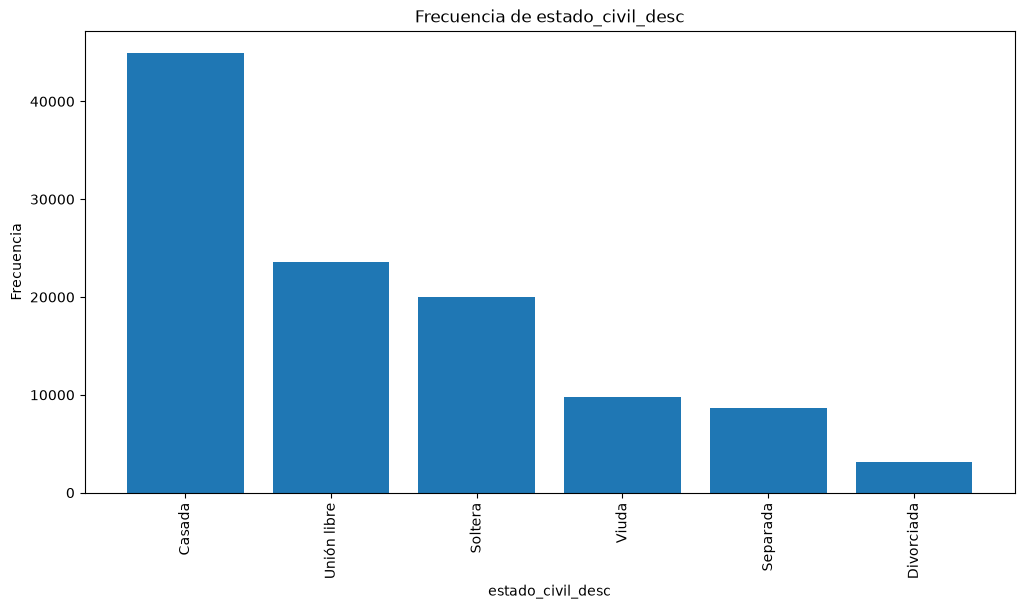

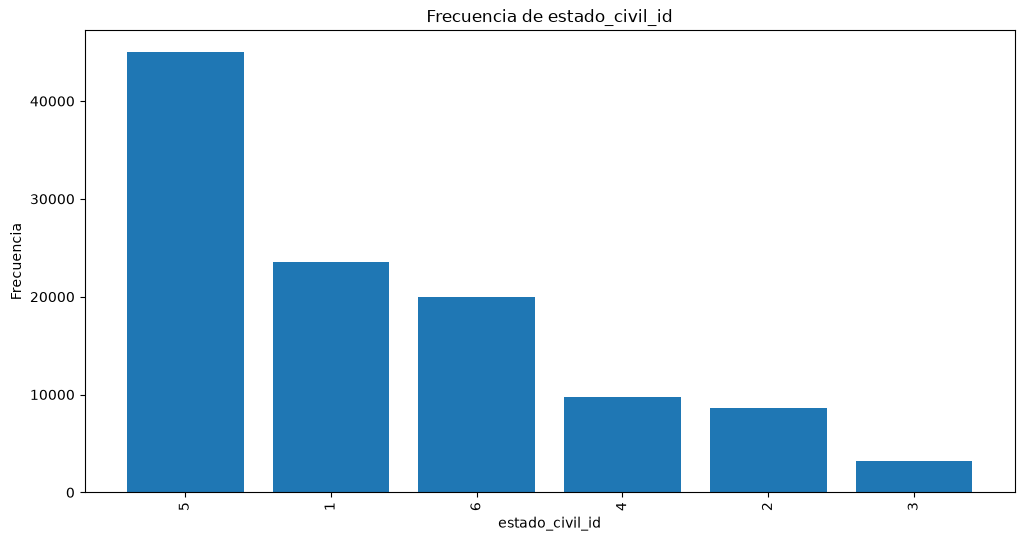

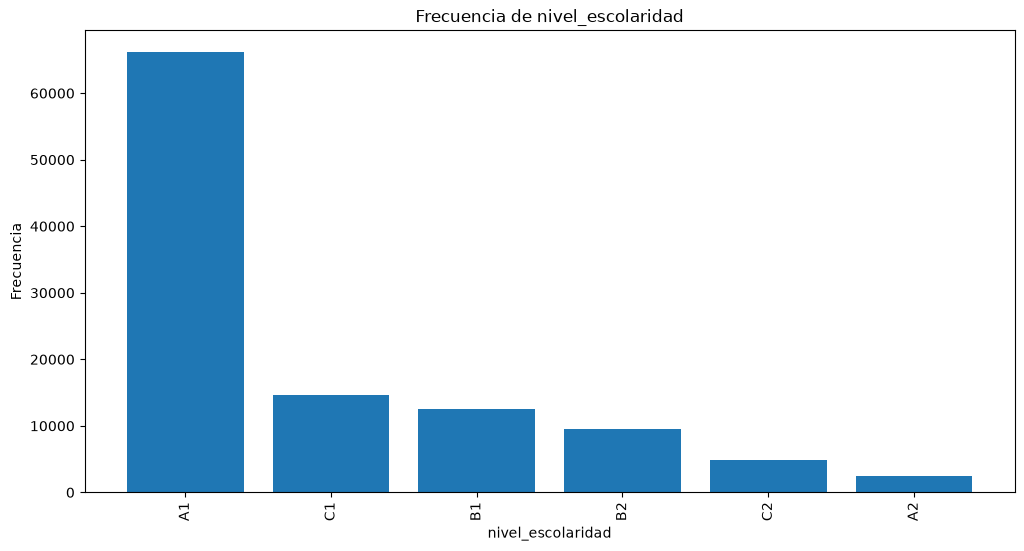

In [86]:
cols = ["estado_civil_desc", "estado_civil_id", "nivel_escolaridad"] 

for col in cols:
    frecuencia = (
        lf.group_by(col)
        .len()
        .sort("len", descending=True)
        .collect()
    )

    plt.figure(figsize=(12, 6))
    plt.bar(
        frecuencia[col].cast(pl.String).to_list(),
        frecuencia["len"].to_list()
    )
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.title(f"Frecuencia de {col}")
    plt.xticks(rotation=90)
    plt.show()

# Cuantitativas

In [90]:
lf.select("ingreso_pareja").describe()

statistic,ingreso_pareja
str,f64
"""count""",48980.0
"""null_count""",61147.0
"""mean""",86351.046039
"""std""",274695.849354
"""min""",0.0
"""25%""",1000.0
"""50%""",1800.0
"""75%""",6000.0
"""max""",9.99999e5


In [91]:
lf.select("ingreso_pareja").unique().collect()

ingreso_pareja
f64
3.0
12800.0
3745.0
25.0
87.0
…
3200.0
525.0
27000.0


<Axes: ylabel='Count'>

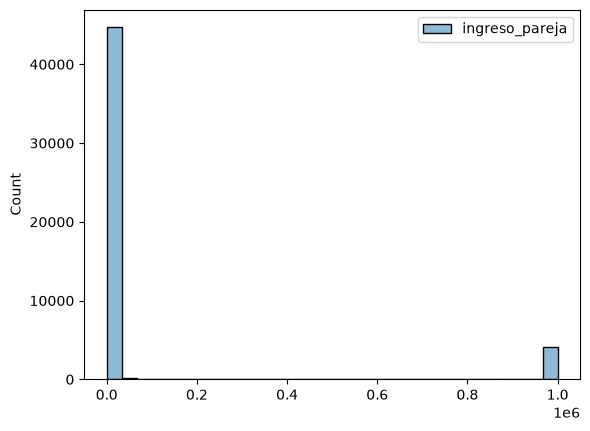

In [94]:
sns.histplot(lf.select("ingreso_pareja").collect().to_pandas(), bins=30)

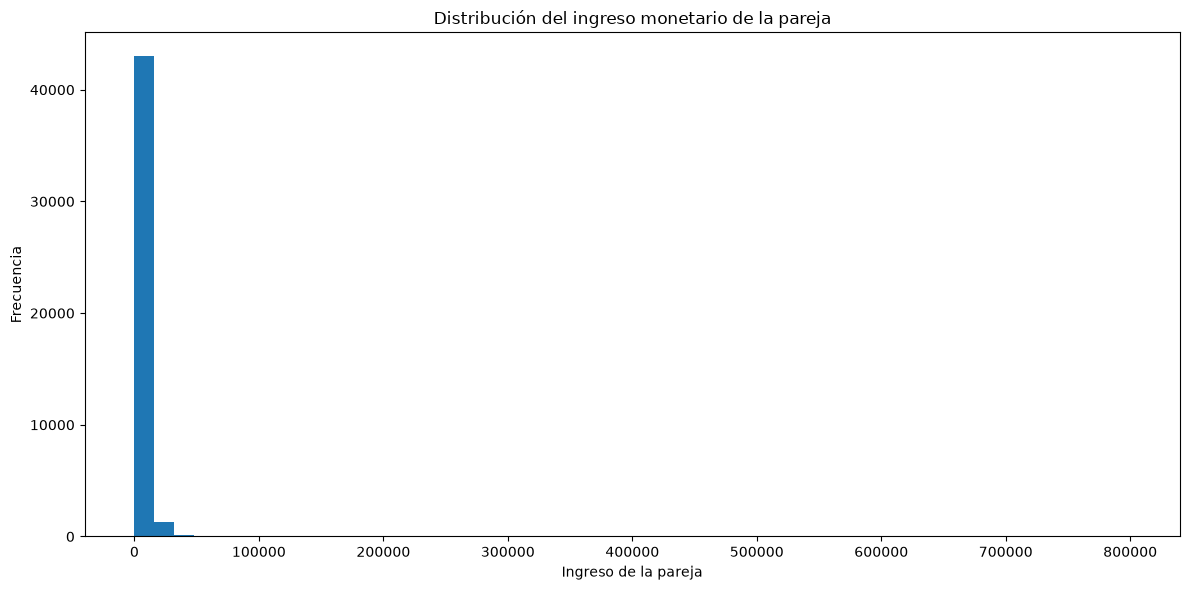

In [95]:
df_ingreso = (
    lf.filter(
        (pl.col("ingreso_pareja") < 999997)
        & (pl.col("ingreso_pareja") > 0)
    )
    .select("ingreso_pareja")
    .collect()
)

plt.figure(figsize=(12, 6))
plt.hist(df_ingreso["ingreso_pareja"].to_list(), bins=50)
plt.xlabel("Ingreso de la pareja")
plt.ylabel("Frecuencia")
plt.title("Distribución del ingreso monetario de la pareja")
plt.tight_layout()
plt.show()

## Valores nulos

In [55]:
nulos = lf.null_count().collect()
nulos

cve_entidad,nom_entidad,cve_municipio,nom_municipio,edad_primer_union,num_hijos,nivel_escolaridad,estado_civil_id,estado_civil_desc,estrato_socioeconomico,pareja_trabaja_id,pareja_trabaja_desc,ingreso_pareja,dinero_propio_id,dinero_propio_desc,apoyo_gobierno_id,apoyo_gobierno_desc,tiene_ahorros_id,tiene_ahorros_desc,propietaria_vivienda_id,propietaria_vivienda_desc,sufrio_violencia_pareja,factor_expansion,anio_encuesta
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,85567,19436,0,0,0,0,0,0,61147,0,0,0,0,0,0,0,0,0,0,0


In [56]:
cols = [col for col in nulos.columns if nulos[col][0] > 0]
print("Columnas con valores nulos:", cols)

Columnas con valores nulos: ['edad_primer_union', 'num_hijos', 'ingreso_pareja']
